# Modelo definitivo para la predicción de rangos salariales

En este notebook desarrollamos la versión definitiva del modelo seleccionado en la comparación de alternativas. El propósito es estimar el salario mínimo (`Y1`) y máximo (`Y2`) anual en dólares estadounidenses, controlar la coherencia de los resultados y revisar su comportamiento frente a la geografía, la experiencia y las habilidades solicitadas.

La unidad de análisis continúa siendo la vacante publicada. El experimento principal utiliza únicamente rangos reportados por las empresas y conserva una separación temporal entre entrenamiento, validación y prueba.

## 0. Alcance y recorrido del modelado

Partimos de los criterios definidos en la exploración y de la comparación realizada en el notebook anterior. El nombre del modelo y sus mejores hiperparámetros se leen directamente del artefacto generado por el notebook 3; de esta manera no se fija manualmente una familia. En esta etapa revisamos nuevamente las variables objetivo, medimos cambios temporales en Y1 y Y2, controlamos categorías nuevas y comparamos la configuración recibida con dos variantes de regularización dentro de la misma familia. Finalmente evaluamos una sola vez el modelo ganador sobre el periodo de prueba y analizamos sus errores por país, experiencia, modalidad y conocimientos.

El objetivo de los diagnósticos no es afirmar que el modelo está libre de error, sino verificar que supera una referencia simple, que su desempeño se mantiene fuera de entrenamiento y que las predicciones permanecen dentro de límites válidos y explicables.

## 1. Preparación del entorno de análisis

Configuramos las librerías, la semilla y el estilo visual con la misma presentación utilizada en el análisis exploratorio. El seguimiento se guarda localmente en MLflow.

In [1]:
from pathlib import Path
from urllib.parse import urldefrag
import json, os, re, sys, warnings
import joblib, mlflow, mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display
from matplotlib import font_manager
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
SEED = 42
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
DATA_DIR, ARTIFACT_DIR = (
    ROOT / "data" / "raw" / "foorilla",
    ROOT / "artifacts",
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
font_files = list((ROOT/'assets'/'fonts').glob('DroidSerif-*.ttf'))
for font_file in font_files: font_manager.fontManager.addfont(font_file)
plt.rcParams.update({'font.family':'Droid Serif' if font_files else 'serif','figure.dpi':120,
                     'axes.spines.top':False,'axes.spines.right':False})
sns.set_theme(style='whitegrid', palette='Blues_d', font='Droid Serif' if font_files else 'serif')
os.environ.setdefault('MLFLOW_ALLOW_FILE_STORE','true')
TRACKING_URI=os.getenv('MLFLOW_TRACKING_URI',(ROOT/'mlruns').resolve().as_uri())
LOG_MODELS_TO_MLFLOW=os.getenv('LOG_MODELS_TO_MLFLOW','false').lower()=='true'
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment('salarios-vacantes-modelo-definitivo')
print({'python':sys.version.split()[0],'pandas':pd.__version__,'sklearn':sklearn.__version__,
       'mlflow':mlflow.__version__,'tracking_uri':TRACKING_URI,
       'registrar_modelos_mlflow':LOG_MODELS_TO_MLFLOW,'semilla':SEED})

{'python': '3.12.11', 'pandas': '3.0.5', 'sklearn': '1.9.0', 'mlflow': '3.16.0', 'tracking_uri': 'file:///Users/franciscolozano/Downloads/PROYECTOS_MAIA/PROYECTO_DE_GRADO/MICROPROYECTO_GITHUB/mlruns', 'registrar_modelos_mlflow': False, 'semilla': 42}


## 2. Integración, republicaciones y procedencia del objetivo

Integramos todos los cortes disponibles y conservamos la versión más reciente y completa de cada identificador. Después construimos una firma con URL, empresa, cargo y ubicación para retirar republicaciones. Y1 y Y2 se toman de los valores convertidos a USD y se clasifican como reportados, híbridos o estimados. Esta separación evita que el modelo principal aprenda principalmente el estimador de Foorilla.

In [2]:
files=sorted(DATA_DIR.glob('jobs_*.csv'))
assert files,'No se encontraron archivos data/jobs_*.csv'
parts=[]
for priority,path in enumerate(files):
    frame=pd.read_csv(path,low_memory=False)
    frame['_priority'],frame['_source_file']=priority,path.name
    parts.append(frame)
raw=pd.concat(parts,ignore_index=True)
raw['published']=pd.to_datetime(raw['published'],errors='coerce',utc=True)
raw['_complete']=raw.notna().sum(axis=1)
by_id=(raw.sort_values(['id','_priority','_complete','published'])
          .drop_duplicates('id',keep='last').copy())

def norm(values):
    return (values.fillna('').astype(str).str.lower().str.normalize('NFKD')
            .str.encode('ascii',errors='ignore').str.decode('ascii')
            .str.replace(r'[^a-z0-9]+',' ',regex=True).str.strip())

url=by_id.apply_url.fillna('').astype(str).map(lambda value:urldefrag(value)[0].rstrip('/').lower())
by_id['_signature']=url+'|'+norm(by_id.company)+'|'+norm(by_id.title)+'|'+norm(by_id.location)
by_id['_salary_info']=by_id[['salary_min','salary_max','salary_min_usd','salary_max_usd']].notna().sum(axis=1)
dedup=(by_id.sort_values(['_signature','company_is_agency','_salary_info','_complete','published'])
          .drop_duplicates('_signature',keep='last').copy())
for side in ['min','max']:
    dedup[f'y_{side}_usd']=pd.to_numeric(dedup[f'salary_{side}_usd'],errors='coerce')
    dedup[f'{side}_reported']=pd.to_numeric(dedup[f'salary_{side}'],errors='coerce').notna()
dedup['target_source']=np.select([dedup.min_reported&dedup.max_reported,
                                  dedup.min_reported|dedup.max_reported],
                                 ['reportado','híbrido'],default='estimado')
complete=dedup.y_min_usd.notna()&dedup.y_max_usd.notna()
positive=complete&(dedup.y_min_usd>0)&(dedup.y_max_usd>0)
ordered=positive&(dedup.y_min_usd<=dedup.y_max_usd)
candidate=dedup.loc[ordered].copy()
log_mid=np.log1p((candidate.y_min_usd+candidate.y_max_usd)/2)
q1,q3=log_mid.quantile([.25,.75]); inlier=log_mid.between(q1-3*(q3-q1),q3+3*(q3-q1))
model_df=candidate.loc[inlier].copy()
display(pd.Series({'filas_integradas':len(raw),'id_unicos':len(by_id),'vacantes_deduplicadas':len(dedup),
                   'y_incompleta':int((~complete).sum()),'y_no_positiva':int((complete&~positive).sum()),
                   'y_invertida':int((positive&~ordered).sum()),'extremos_retirados':int((~inlier).sum()),
                   'muestra_modelado':len(model_df),'rangos_reportados':int(model_df.target_source.eq('reportado').sum())}))

filas_integradas         333773
id_unicos                333422
vacantes_deduplicadas    283551
y_incompleta              23352
y_no_positiva                 5
y_invertida                  11
extremos_retirados           25
muestra_modelado         260158
rangos_reportados         54363
dtype: int64

## 3. Validación de Y1 y Y2 en los periodos temporales

Antes de entrenar verificamos que los nuevos valores objetivo permanezcan positivos, completos y ordenados. También comparamos tamaño, mediana y percentiles por partición. Una diferencia entre periodos no constituye fuga de información, pero sí puede explicar una reducción del desempeño fuera de entrenamiento y debe permanecer visible en la interpretación.

In [3]:
reported=model_df.loc[model_df.target_source.eq('reportado')].sort_values('published',na_position='first')
n=len(reported); a,b=int(.70*n),int(.85*n)
train_idx,val_idx,test_idx=reported.index[:a],reported.index[a:b],reported.index[b:]
split_map={**dict.fromkeys(train_idx,'entrenamiento'),**dict.fromkeys(val_idx,'validación'),
           **dict.fromkeys(test_idx,'prueba')}
reported['particion']=reported.index.map(split_map)
target_profile=(reported.groupby('particion',observed=True)
    .agg(n=('id','size'),fecha_inicial=('published','min'),fecha_final=('published','max'),
         y1_p05=('y_min_usd',lambda s:s.quantile(.05)),y1_mediana=('y_min_usd','median'),
         y1_p95=('y_min_usd',lambda s:s.quantile(.95)),y2_p05=('y_max_usd',lambda s:s.quantile(.05)),
         y2_mediana=('y_max_usd','median'),y2_p95=('y_max_usd',lambda s:s.quantile(.95))))
display(target_profile)
assert (reported.y_min_usd>0).all() and (reported.y_max_usd>0).all()
assert (reported.y_min_usd<=reported.y_max_usd).all()
train_limits={'floor':max(1000,float(reported.loc[train_idx,'y_min_usd'].quantile(.001))),
              'ceiling':float(reported.loc[train_idx,'y_max_usd'].quantile(.999))}
outside=pd.DataFrame({
    'particion':['validación','prueba'],
    'y1_fuera_soporte_train':[np.mean(~reported.loc[val_idx,'y_min_usd'].between(reported.loc[train_idx,'y_min_usd'].min(),reported.loc[train_idx,'y_min_usd'].max())),
                              np.mean(~reported.loc[test_idx,'y_min_usd'].between(reported.loc[train_idx,'y_min_usd'].min(),reported.loc[train_idx,'y_min_usd'].max()))],
    'y2_fuera_soporte_train':[np.mean(~reported.loc[val_idx,'y_max_usd'].between(reported.loc[train_idx,'y_max_usd'].min(),reported.loc[train_idx,'y_max_usd'].max())),
                              np.mean(~reported.loc[test_idx,'y_max_usd'].between(reported.loc[train_idx,'y_max_usd'].min(),reported.loc[train_idx,'y_max_usd'].max()))]})
display(outside.style.format({'y1_fuera_soporte_train':'{:.2%}','y2_fuera_soporte_train':'{:.2%}'}))
print('Límites operativos aprendidos solo con entrenamiento:',train_limits)

,n,fecha_inicial,fecha_final,y1_p05,y1_mediana,y1_p95,y2_p05,y2_mediana,y2_p95
particion,,,,,,,,,
entrenamiento,38054,2025-01-01 00:13:20+00:00,2026-03-03 00:00:00+00:00,56186.0,130000.0,224000.0,91000.0,200000.0,339000.0
prueba,8155,2026-05-26 00:00:00+00:00,2026-09-01 05:37:04+00:00,49776.0,128000.0,225000.0,69935.0,184000.0,340000.0
validación,8154,2026-03-03 00:00:00+00:00,2026-05-26 00:00:00+00:00,54000.0,130400.0,235350.0,76000.0,190000.0,356500.0


,particion,y1_fuera_soporte_train,y2_fuera_soporte_train
0,validación,0.01%,0.02%
1,prueba,0.01%,0.01%


Límites operativos aprendidos solo con entrenamiento: {'floor': 10935.571999999996, 'ceiling': 720000.0}


## 4. Ingeniería de variables y categorías nuevas

Construimos las mismas variables definidas en el EDA: cargo, geografía, experiencia, modalidad, empresa, condición de agencia y habilidades. Si el ganador usa el preprocesamiento general, las categorías pasan por `TargetEncoder`, cuyo ajuste cruzado reduce el riesgo de memorizar empresas o cargos y asigna la media global ante valores nuevos. Si CatBoost resulta ganador, conserva su tratamiento categórico nativo. Cada objetivo ajusta sus transformaciones exclusivamente con entrenamiento.

In [4]:
SKILLS={'python':'python','sql':'sql','aws':'aws','azure':'azure','gcp':'gcp','spark':'spark',
        'docker':'docker','kubernetes':'kubernetes','machine_learning':'machine learning',
        'pytorch':'pytorch','tensorflow':'tensorflow','tableau':'tableau','power_bi':'power bi'}
def prepare_features(df):
    out=pd.DataFrame(index=df.index)
    out['title']=norm(df.title).replace('','desconocido')
    out['country']=df.countries.fillna('desconocido').astype(str).str.split('|').str[0].str.strip().replace('','desconocido')
    out['region']=df.regions.fillna('desconocido').astype(str).str.split('|').str[0].str.strip().replace('','desconocido')
    out['experience_level']=df.experience_level.fillna('desconocido').astype(str)
    remote=df.has_remote.fillna(False).astype(bool); work=pd.to_numeric(df.work_mode,errors='coerce')
    out['work_mode']=np.select([~remote,work.eq(1),work.eq(2),work.eq(3)],
                               ['presencial','híbrido','remoto','remoto_global'],default='remoto_sin_detalle')
    out['company']=norm(df.company).replace('','desconocido')
    out['company_is_agency']=df.company_is_agency.fillna(False).astype(int)
    years=pd.to_numeric(df.experience_years,errors='coerce')
    out['experience_years']=years.where(years.between(0,50))
    out['experience_years_missing']=out.experience_years.isna().astype(int)
    tags=df.tags.fillna('').astype(str).str.lower()
    for name,token in SKILLS.items():out[f'skill_{name}']=tags.str.contains(re.escape(token),regex=True).astype(int)
    out['published_year'],out['published_month']=df.published.dt.year,df.published.dt.month
    return out

X=prepare_features(model_df); TARGETS=['y_min_usd','y_max_usd']
cat_cols=['title','country','region','experience_level','work_mode','company']
num_cols=[column for column in X if column not in cat_cols]
assert not [column for column in X if 'salary' in column.lower()]
selection_path=ROOT/'artifacts'/'comparacion_modelos'/'seleccion_modelo.json'
assert selection_path.exists(),'Primero debe ejecutarse notebooks/03_experimentos_modelos.ipynb'
with open(selection_path) as file:comparison_selection=json.load(file)
selected_model=comparison_selection['modelo_seleccionado']
selected_params=comparison_selection['parametros']
supported={'ridge','hist_gradient_boosting','gradient_boosting','random_forest','extra_trees',
           'lightgbm','xgboost','catboost'}
assert selected_model in supported,f'Modelo no soportado en notebook 04: {selected_model}'
assert comparison_selection['feature_columns']==list(X.columns),'El contrato de variables cambió entre los notebooks 03 y 04'
assert comparison_selection['categorical_columns']==cat_cols,'Las variables categóricas no coinciden con el notebook 03'
display(pd.Series({'modelo_recibido':comparison_selection['modelo_seleccionado'],
                   'familia':comparison_selection['familia'],
                   'preprocesamiento':comparison_selection['preprocesamiento'],
                   'mejor_configuración_notebook_3':comparison_selection['configuracion_seleccionada'],
                   'hiperparámetros':json.dumps(selected_params,ensure_ascii=False),
                   'numero_variables':len(comparison_selection['feature_columns'])}))
novelty=[]
for column in cat_cols:
    known=set(X.loc[train_idx,column]);
    for label,index in [('validación',val_idx),('prueba',test_idx)]:
        novelty.append({'variable':column,'particion':label,'categorias_train':len(known),
                        'categorias_nuevas':len(set(X.loc[index,column])-known),
                        'filas_categoria_nueva':np.mean(~X.loc[index,column].isin(known))})
novelty=pd.DataFrame(novelty)
display(novelty.style.format({'filas_categoria_nueva':'{:.1%}'}))

modelo_recibido                                                            lightgbm
familia                                                      boosting especializado
preprocesamiento                                                      TargetEncoder
mejor_configuración_notebook_3                                         lightgbm__03
hiperparámetros                   {"objective": "regression_l1", "verbosity": -1...
numero_variables                                                                 24
dtype: object

,variable,particion,categorias_train,categorias_nuevas,filas_categoria_nueva
0,title,validación,19045,3661,54.0%
1,title,prueba,19045,3792,62.0%
2,country,validación,76,5,0.1%
3,country,prueba,76,8,0.4%
4,region,validación,7,0,0.0%
5,region,prueba,7,0,0.0%
6,experience_level,validación,5,0,0.0%
7,experience_level,prueba,5,0,0.0%
8,work_mode,validación,5,0,0.0%
9,work_mode,prueba,5,0,0.0%


## 5. Protocolo de evaluación y coherencia del rango

Transformamos Y1 y Y2 con `log1p` para reducir el efecto de la asimetría y revertimos la transformación al evaluar. Después aplicamos tres controles operativos: salarios positivos, límites dentro del soporte robusto aprendido en entrenamiento y orden `Y1 ≤ Y2`. Conservamos también la incoherencia anterior al ajuste para conocer con qué frecuencia los dos modelos independientes se cruzan.

In [5]:
preprocessor=ColumnTransformer([
    ('categoricas',Pipeline([('imputar',SimpleImputer(strategy='most_frequent')),
                             ('codificar',TargetEncoder(target_type='continuous',smooth='auto',cv=5,
                                                       shuffle=True,random_state=SEED))]),cat_cols),
    ('numericas',SimpleImputer(strategy='median'),num_cols)],verbose_feature_names_out=False)

def postprocess(raw_prediction,limits=train_limits):
    clipped=np.clip(np.asarray(raw_prediction,dtype=float),limits['floor'],limits['ceiling'])
    return np.sort(clipped,axis=1)

def metrics(y_true,raw_prediction):
    prediction=postprocess(raw_prediction); result={}
    for j,label in enumerate(['min','max']):
        result[f'mae_{label}']=mean_absolute_error(y_true[:,j],prediction[:,j])
        result[f'rmse_{label}']=mean_squared_error(y_true[:,j],prediction[:,j])**.5
        result[f'mape_{label}']=mean_absolute_percentage_error(y_true[:,j],prediction[:,j])
        result[f'r2_{label}']=r2_score(y_true[:,j],prediction[:,j])
    result['mae_promedio']=(result['mae_min']+result['mae_max'])/2
    result['mae_amplitud']=mean_absolute_error(y_true[:,1]-y_true[:,0],prediction[:,1]-prediction[:,0])
    result['cobertura_intervalo']=np.mean((y_true[:,0]>=prediction[:,0])&(y_true[:,1]<=prediction[:,1]))
    result['incoherencia_raw']=np.mean(raw_prediction[:,0]>raw_prediction[:,1])
    result['prediccion_no_positiva']=np.mean(prediction<=0)
    return result,prediction

def build_estimator(params):
    if selected_model=='ridge':return Ridge(**params)
    if selected_model=='hist_gradient_boosting':return HistGradientBoostingRegressor(**params,random_state=SEED)
    if selected_model=='gradient_boosting':return GradientBoostingRegressor(**params,random_state=SEED)
    if selected_model=='random_forest':return RandomForestRegressor(**params,n_jobs=-1,random_state=SEED)
    if selected_model=='extra_trees':return ExtraTreesRegressor(**params,n_jobs=-1,random_state=SEED)
    if selected_model=='lightgbm':return LGBMRegressor(**params,n_jobs=-1,random_state=SEED)
    if selected_model=='xgboost':return XGBRegressor(**params,n_jobs=-1,random_state=SEED)
    if selected_model=='catboost':return CatBoostRegressor(**params,cat_features=cat_cols,
                                                           thread_count=-1,random_seed=SEED)
    raise KeyError(selected_model)

def fit_and_evaluate(name,params,train_rows,eval_rows,stage='validación'):
    fitted=[];raw_eval=[]
    with mlflow.start_run(run_name=f'{stage}-{name}') as run:
        mlflow.log_params({'modelo':selected_model,'configuracion':name,'stage':stage,'seed':SEED,
                           'n_train':len(train_rows),'n_eval':len(eval_rows),
                           'preprocesamiento':comparison_selection['preprocesamiento'],**params})
        for target in TARGETS:
            y_log=np.log1p(model_df.loc[train_rows,target])
            estimator=build_estimator(params)
            if selected_model=='catboost':
                fitted_model=estimator.fit(X.loc[train_rows],y_log)
            else:
                steps=[('preprocesamiento',clone(preprocessor))]
                if selected_model=='ridge':steps.append(('estandarizacion',StandardScaler()))
                steps.append(('modelo',estimator))
                fitted_model=Pipeline(steps).fit(X.loc[train_rows],y_log)
            fitted.append(fitted_model)
            raw_eval.append(np.expm1(fitted_model.predict(X.loc[eval_rows])))
        eval_scores,eval_prediction=metrics(model_df.loc[eval_rows,TARGETS].to_numpy(),np.column_stack(raw_eval))
        result={'configuracion':name,'parametros':json.dumps(params,ensure_ascii=False),
                **{f'val_{k}':v for k,v in eval_scores.items()}}
        mlflow.log_metrics({k:v for k,v in result.items() if isinstance(v,(int,float,np.floating))})
        if LOG_MODELS_TO_MLFLOW:
            for target,fitted_model in zip(TARGETS,fitted):
                mlflow.sklearn.log_model(fitted_model,name=f'{target}_{name}',
                    serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE)
        return result,fitted,eval_prediction

## 6. Línea base y ajuste dentro del modelo seleccionado

Comparamos la mejor configuración recibida del notebook 3 con una alternativa más regularizada y otra más flexible de la misma familia. Los cambios se aplican a los parámetros que controlan la complejidad de cada algoritmo. La selección se realiza únicamente con validación temporal y exigimos una mejora mínima del 10% frente a la mediana histórica para descartar subajuste evidente.

In [6]:
def baseline_metrics(train_rows,eval_rows):
    raw=[]
    for target in TARGETS:
        model=DummyRegressor(strategy='median').fit(np.zeros((len(train_rows),1)),np.log1p(model_df.loc[train_rows,target]))
        raw.append(np.expm1(model.predict(np.zeros((len(eval_rows),1)))))
    return metrics(model_df.loc[eval_rows,TARGETS].to_numpy(),np.column_stack(raw))[0]

baseline=baseline_metrics(train_idx,val_idx)

def configuration_variants(model_name,best):
    received=dict(best);regularized=dict(best);flexible=dict(best)
    if model_name=='ridge':
        regularized['alpha']=float(best['alpha'])*10;flexible['alpha']=max(float(best['alpha'])/10,.001)
    elif model_name=='hist_gradient_boosting':
        regularized.update(max_leaf_nodes=max(7,int(best['max_leaf_nodes'])//2),
                           min_samples_leaf=int(best['min_samples_leaf'])*2,
                           l2_regularization=float(best['l2_regularization'])*3)
        flexible.update(max_leaf_nodes=min(127,int(best['max_leaf_nodes'])*2),
                        min_samples_leaf=max(5,int(best['min_samples_leaf'])//2),
                        l2_regularization=max(.1,float(best['l2_regularization'])/2))
    elif model_name=='gradient_boosting':
        regularized.update(max_depth=max(1,int(best['max_depth'])-1),
                           min_samples_leaf=int(best['min_samples_leaf'])*2,subsample=.8)
        flexible.update(max_depth=int(best['max_depth'])+1,
                        min_samples_leaf=max(2,int(best['min_samples_leaf'])//2),subsample=1.0)
    elif model_name in {'random_forest','extra_trees'}:
        current_depth=best.get('max_depth') or 30
        regularized.update(max_depth=max(10,int(current_depth)-6),
                           min_samples_leaf=int(best['min_samples_leaf'])*2,
                           max_features=min(.75,float(best['max_features'])))
        flexible.update(max_depth=None,min_samples_leaf=max(1,int(best['min_samples_leaf'])//2),
                        max_features=min(1.0,float(best['max_features'])+.15))
    elif model_name=='lightgbm':
        regularized.update(num_leaves=max(15,int(best['num_leaves'])//2),
                           min_child_samples=int(best['min_child_samples'])*2,
                           reg_lambda=float(best['reg_lambda'])*3)
        flexible.update(num_leaves=min(127,int(best['num_leaves'])+32),
                        min_child_samples=max(10,int(best['min_child_samples'])//2),
                        reg_lambda=max(.1,float(best['reg_lambda'])/2))
    elif model_name=='xgboost':
        regularized.update(max_depth=max(3,int(best['max_depth'])-2),
                           min_child_weight=float(best['min_child_weight'])*2,
                           reg_lambda=float(best['reg_lambda'])*3)
        flexible.update(max_depth=min(12,int(best['max_depth'])+2),
                        min_child_weight=max(1,float(best['min_child_weight'])/2),
                        reg_lambda=max(.1,float(best['reg_lambda'])/2))
    elif model_name=='catboost':
        regularized.update(depth=max(4,int(best['depth'])-2),l2_leaf_reg=float(best['l2_leaf_reg'])*2,
                           random_strength=float(best['random_strength'])*1.5)
        flexible.update(depth=min(10,int(best['depth'])+1),
                        l2_leaf_reg=max(1,float(best['l2_leaf_reg'])/2),
                        random_strength=max(.1,float(best['random_strength'])/2))
    return {'recibida_notebook_3':received,'más_regularizada':regularized,'más_flexible':flexible}

configurations=configuration_variants(selected_model,selected_params)
display(pd.DataFrame([{'configuracion':name,'hiperparametros':json.dumps(params,ensure_ascii=False)}
                      for name,params in configurations.items()]))
results=[];candidate_predictions={}
for name,params in configurations.items():
    result,_,validation_prediction=fit_and_evaluate(name,params,train_idx,val_idx)
    result['mejora_vs_baseline']=1-result['val_mae_promedio']/baseline['mae_promedio']
    results.append(result);candidate_predictions[name]=validation_prediction
leaderboard=pd.DataFrame(results).sort_values('val_mae_promedio').reset_index(drop=True)
display(leaderboard[['configuracion','parametros','val_mae_promedio','mejora_vs_baseline',
                     'val_r2_min','val_r2_max','val_mae_amplitud',
                     'val_cobertura_intervalo','val_incoherencia_raw']].style.format({
    'val_mae_promedio':'USD {:,.0f}','mejora_vs_baseline':'{:.1%}',
    'val_r2_min':'{:.3f}','val_r2_max':'{:.3f}',
    'val_mae_amplitud':'USD {:,.0f}','val_cobertura_intervalo':'{:.1%}','val_incoherencia_raw':'{:.2%}'}))
eligible=leaderboard[leaderboard.mejora_vs_baseline>=.10]
winner=(eligible if len(eligible) else leaderboard).iloc[0].configuracion
print('Configuración seleccionada:',winner)

,configuracion,hiperparametros
0,recibida_notebook_3,"{""objective"": ""regression_l1"", ""verbosity"": -1..."
1,más_regularizada,"{""objective"": ""regression_l1"", ""verbosity"": -1..."
2,más_flexible,"{""objective"": ""regression_l1"", ""verbosity"": -1..."


,configuracion,parametros,val_mae_promedio,mejora_vs_baseline,val_r2_min,val_r2_max,val_mae_amplitud,val_cobertura_intervalo,val_incoherencia_raw
0,recibida_notebook_3,"{""objective"": ""regression_l1"", ""verbosity"": -1, ""subsample_freq"": 1, ""subsample"": 0.8, ""reg_lambda"": 3.0, ""num_leaves"": 95, ""n_estimators"": 700, ""min_child_samples"": 20, ""learning_rate"": 0.06, ""colsample_bytree"": 1.0}","USD 26,148",53.3%,0.641,0.693,"USD 20,636",15.1%,1.02%
1,más_flexible,"{""objective"": ""regression_l1"", ""verbosity"": -1, ""subsample_freq"": 1, ""subsample"": 0.8, ""reg_lambda"": 1.5, ""num_leaves"": 127, ""n_estimators"": 700, ""min_child_samples"": 10, ""learning_rate"": 0.06, ""colsample_bytree"": 1.0}","USD 26,252",53.1%,0.640,0.695,"USD 20,931",15.8%,0.94%
2,más_regularizada,"{""objective"": ""regression_l1"", ""verbosity"": -1, ""subsample_freq"": 1, ""subsample"": 0.8, ""reg_lambda"": 9.0, ""num_leaves"": 47, ""n_estimators"": 700, ""min_child_samples"": 40, ""learning_rate"": 0.06, ""colsample_bytree"": 1.0}","USD 26,406",52.9%,0.633,0.690,"USD 20,650",14.5%,0.91%


Configuración seleccionada: recibida_notebook_3


## 7. Diagnóstico temporal de subajuste y sobreajuste

No es posible garantizar que un modelo nunca presente subajuste o sobreajuste; sí podemos buscar evidencia y establecer controles. Consideramos que existe capacidad predictiva cuando mejora al menos 10% sobre la línea base. Para revisar estabilidad entrenamos la configuración seleccionada con el 80% más antiguo del conjunto de entrenamiento y la evaluamos sobre el 20% siguiente. Después comparamos este retrotest con la validación temporal externa. Una diferencia relativa menor o igual al 25% se toma como señal de estabilidad, no como una prueba absoluta.

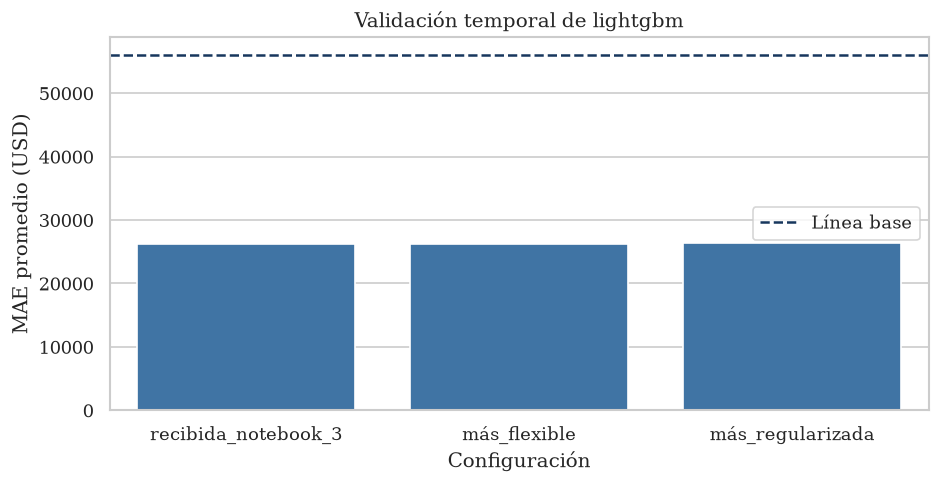

La configuración recibida_notebook_3 mejora 53.3% frente a la línea base. El retrotest obtuvo MAE USD 25,143 y la validación USD 26,148; la diferencia relativa es 4.0%.
Estabilidad temporal dentro del umbral del 25%: True
Diagnóstico de subajuste: sin evidencia fuerte
Diagnóstico de sobreajuste: sin evidencia temporal fuerte


In [7]:
fig,ax=plt.subplots(figsize=(8,4.2))
sns.barplot(data=leaderboard,x='configuracion',y='val_mae_promedio',color='#2F75B5',ax=ax)
ax.axhline(baseline['mae_promedio'],color='#17365D',linestyle='--',label='Línea base')
ax.set(xlabel='Configuración',ylabel='MAE promedio (USD)',title=f'Validación temporal de {selected_model}')
ax.legend(); plt.tight_layout(); plt.show()
selected_row=leaderboard.set_index('configuracion').loc[winner]
back_cut=int(.80*len(train_idx)); back_train,back_eval=train_idx[:back_cut],train_idx[back_cut:]
back_result,_,_=fit_and_evaluate('retrotest_'+winner,configurations[winner],back_train,back_eval,stage='retrotest_temporal')
back_mae=back_result['val_mae_promedio']; temporal_gap=(selected_row.val_mae_promedio-back_mae)/back_mae
stable=bool(abs(temporal_gap)<=.25)
print(f"La configuración {winner} mejora {selected_row.mejora_vs_baseline:.1%} frente a la línea base. "
      f"El retrotest obtuvo MAE USD {back_mae:,.0f} y la validación USD {selected_row.val_mae_promedio:,.0f}; "
      f"la diferencia relativa es {temporal_gap:.1%}.")
print('Estabilidad temporal dentro del umbral del 25%:',stable)
print('Diagnóstico de subajuste:', 'sin evidencia fuerte' if selected_row.mejora_vs_baseline>=.10 else 'revisar capacidad')
print('Diagnóstico de sobreajuste:', 'sin evidencia temporal fuerte' if stable else 'requiere mayor regularización')

## 8. Entrenamiento definitivo y evaluación temporal reservada

Después de seleccionar la configuración sin observar la prueba, unimos entrenamiento y validación, ajustamos nuevamente los dos pipelines y evaluamos una sola vez sobre el periodo más reciente. Esta cifra representa la estimación más realista del desempeño esperado ante vacantes nuevas del mismo origen. Adicionalmente calculamos en validación un margen conjunto de incertidumbre con cobertura nominal del 80%; este margen no cambia Y1/Y2, sino que informa cuánto pueden variar frente a vacantes futuras.

In [8]:
trainval_idx=train_idx.append(val_idx)
validation_true=model_df.loc[val_idx,TARGETS].to_numpy()
validation_error=np.max(np.abs(validation_true-candidate_predictions[winner]),axis=1)
uncertainty_margin=float(np.quantile(validation_error,.80,method='higher'))
final_result,final_models,test_prediction=fit_and_evaluate('definitivo_'+winner,configurations[winner],trainval_idx,test_idx,stage='prueba_final')
test_scores={key.removeprefix('val_'):value for key,value in final_result.items() if key.startswith('val_')}
test_true=model_df.loc[test_idx,TARGETS].to_numpy()
uncertainty_coverage=float(np.mean(np.max(np.abs(test_true-test_prediction),axis=1)<=uncertainty_margin))
display(pd.Series(test_scores).rename('prueba_final'))
print(f"MAE promedio final: USD {test_scores['mae_promedio']:,.0f}. "
      f"R² mínimo/máximo: {test_scores['r2_min']:.3f}/{test_scores['r2_max']:.3f}.")
print(f"Margen conjunto de incertidumbre: ±USD {uncertainty_margin:,.0f}; "
      f"cobertura observada en prueba: {uncertainty_coverage:.1%}.")

mae_min                   22421.612448
rmse_min                  40309.393960
mape_min                      0.258957
r2_min                        0.569988
mae_max                   32070.180352
rmse_max                  54839.237342
mape_max                      0.242499
r2_max                        0.623504
mae_promedio              27245.896400
mae_amplitud              21605.277013
cobertura_intervalo           0.119559
incoherencia_raw              0.006499
prediccion_no_positiva        0.000000
Name: prueba_final, dtype: float64

MAE promedio final: USD 27,246. R² mínimo/máximo: 0.570/0.624.
Margen conjunto de incertidumbre: ±USD 51,504; cobertura observada en prueba: 78.8%.


## 9. Calidad de predicciones nuevas

Verificamos que todas las predicciones sean finitas, positivas, estén ordenadas y permanezcan dentro de los límites aprendidos. Además probamos un perfil completamente nuevo para comprobar que el codificador pueda procesar un país, empresa y cargo no observados sin producir errores ni valores incoherentes.

In [9]:
def predict_range(features):
    missing=set(X.columns)-set(features.columns)
    if missing:raise ValueError(f'Faltan variables: {sorted(missing)}')
    raw=np.column_stack([np.expm1(model.predict(features[X.columns])) for model in final_models])
    prediction=postprocess(raw)
    if not np.isfinite(prediction).all():raise ValueError('La predicción contiene valores no finitos')
    return prediction

def predict_with_uncertainty(features):
    prediction=predict_range(features)
    lower=np.maximum(train_limits['floor'],prediction-uncertainty_margin)
    upper=np.minimum(train_limits['ceiling'],prediction+uncertainty_margin)
    return prediction,lower,upper

checks={'valores_finitos':bool(np.isfinite(test_prediction).all()),
        'valores_positivos':bool((test_prediction>0).all()),
        'rangos_ordenados':bool((test_prediction[:,0]<=test_prediction[:,1]).all()),
        'dentro_limites_operativos':bool((test_prediction>=train_limits['floor']).all() and
                                         (test_prediction<=train_limits['ceiling']).all())}
base={column:(X.loc[trainval_idx,column].mode().iloc[0] if column in cat_cols else
              float(X.loc[trainval_idx,column].median())) for column in X.columns}
new_profile=pd.DataFrame([{**base,'title':'cargo completamente nuevo','country':'pais no observado',
                           'region':'region no observada','company':'empresa no observada',
                           'experience_level':'MI','experience_years':4}])
new_prediction=predict_range(new_profile)[0]
display(pd.Series({**checks,'nuevo_y1':new_prediction[0],'nuevo_y2':new_prediction[1]}))
assert all(checks.values()) and new_prediction[0]<=new_prediction[1]

valores_finitos                       True
valores_positivos                     True
rangos_ordenados                      True
dentro_limites_operativos             True
nuevo_y1                     102718.309411
nuevo_y2                     163361.306418
dtype: object

## 10. Desempeño por geografía, experiencia y modalidad

Las métricas agregadas pueden ocultar errores concentrados. Comparamos valores observados y predichos en segmentos con al menos 50 vacantes. El sesgo se calcula como predicción menos valor observado; un resultado positivo indica sobreestimación y uno negativo subestimación. Los segmentos con menor soporte deben generar una advertencia en el tablero.

In [10]:
audit=model_df.loc[test_idx,['id','countries','experience_level','experience_years','has_remote','work_mode']].copy()
audit[['y1','y2']]=model_df.loc[test_idx,TARGETS]
audit[['pred_y1','pred_y2']]=test_prediction
audit['observado']=(audit.y1+audit.y2)/2; audit['predicho']=(audit.pred_y1+audit.pred_y2)/2
audit['error_absoluto']=abs(audit.observado-audit.predicho); audit['sesgo']=audit.predicho-audit.observado
audit['country']=audit.countries.fillna('desconocido').astype(str).str.split('|').str[0].str.strip()
audit['years_clean']=pd.to_numeric(audit.experience_years,errors='coerce').where(lambda x:x.between(0,50))
audit['years_group']=pd.cut(audit.years_clean,[-.1,2,5,10,50],labels=['0-2','3-5','6-10','11+'])
remote=audit.has_remote.fillna(False).astype(bool); work=pd.to_numeric(audit.work_mode,errors='coerce')
audit['modalidad']=np.select([~remote,work.eq(1),work.eq(2),work.eq(3)],
                             ['presencial','híbrido','remoto','remoto_global'],default='remoto_sin_detalle')

def segment_table(column,min_n=50):
    return (audit.groupby(column,dropna=False,observed=True)
            .agg(n=('id','size'),mediana_observada=('observado','median'),mediana_predicha=('predicho','median'),
                 mae=('error_absoluto','mean'),sesgo=('sesgo','mean')).query('n>=@min_n').sort_values('n',ascending=False))

country_audit=segment_table('country'); experience_audit=segment_table('experience_level')
years_audit=segment_table('years_group'); mode_audit=segment_table('modalidad')
display(country_audit.head(15).style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))
display(experience_audit.style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))
display(years_audit.style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))
display(mode_audit.style.format({c:'USD {:,.0f}' for c in ['mediana_observada','mediana_predicha','mae','sesgo']}))

novel_audit=[]
for column in ['title','company','country']:
    known=set(X.loc[trainval_idx,column])
    flag=np.where(X.loc[test_idx,column].isin(known),'conocida','nueva')
    temp=audit.assign(estado_categoria=flag).groupby('estado_categoria').agg(
        n=('id','size'),mae=('error_absoluto','mean'),sesgo=('sesgo','mean')).reset_index()
    temp.insert(0,'variable',column);novel_audit.append(temp)
novel_audit=pd.concat(novel_audit,ignore_index=True)
display(novel_audit.style.format({'mae':'USD {:,.0f}','sesgo':'USD {:,.0f}'}))

,n,mediana_observada,mediana_predicha,mae,sesgo
country,,,,,
United States,6466,"USD 167,950","USD 167,029","USD 23,871","USD -2,535"
Canada,398,"USD 105,206","USD 108,783","USD 22,464",USD -271
India,158,"USD 36,527","USD 37,825","USD 32,709","USD -9,106"
desconocido,131,"USD 149,177","USD 149,377","USD 30,094","USD 1,990"
Poland,109,"USD 80,000","USD 74,751","USD 22,431","USD -2,978"
Cuba,99,"USD 235,750","USD 251,216","USD 24,275","USD 10,137"
United Kingdom,72,"USD 102,858","USD 104,152","USD 28,015","USD -9,040"
Costa Rica,64,"USD 222,400","USD 127,057","USD 91,184","USD -91,184"


,n,mediana_observada,mediana_predicha,mae,sesgo
experience_level,,,,,
SE,5145,"USD 172,500","USD 169,810","USD 25,372","USD -3,199"
MI,2417,"USD 132,000","USD 135,796","USD 24,810","USD -1,596"
EN,383,"USD 110,000","USD 108,086","USD 27,942","USD -9,297"
EX,200,"USD 200,000","USD 203,591","USD 33,180","USD -1,655"


,n,mediana_observada,mediana_predicha,mae,sesgo
years_group,,,,,
3-5,3763,"USD 147,925","USD 150,455","USD 25,053","USD -1,402"
6-10,2886,"USD 179,225","USD 174,770","USD 25,893","USD -4,286"
0-2,1212,"USD 126,750","USD 120,298","USD 25,157","USD -3,930"
11+,294,"USD 225,000","USD 211,708","USD 30,161","USD -7,608"


,n,mediana_observada,mediana_predicha,mae,sesgo
modalidad,,,,,
presencial,5455,"USD 168,000","USD 164,794","USD 26,495","USD -4,942"
remoto,1616,"USD 125,000","USD 139,609","USD 23,056",USD 783
remoto_sin_detalle,763,"USD 140,000","USD 147,935","USD 26,341","USD 2,927"
híbrido,312,"USD 184,950","USD 171,912","USD 20,077","USD -4,452"


,variable,estado_categoria,n,mae,sesgo
0,title,conocida,3767,"USD 20,940",USD -171
1,title,nueva,4388,"USD 29,506","USD -5,469"
2,company,conocida,7083,"USD 24,342","USD -3,253"
3,company,nueva,1072,"USD 33,527","USD -1,498"
4,country,conocida,8127,"USD 25,553","USD -3,091"
5,country,nueva,28,"USD 24,603","USD 16,867"


## 11. Sensibilidad controlada de experiencia y geografía

Construimos perfiles comparables modificando una dimensión a la vez. Esta prueba no demuestra causalidad, pero permite detectar respuestas contrarias a patrones básicos del mercado. En experiencia esperamos una progresión general entre entrada, nivel medio, senior y ejecutivo. En geografía comparamos la predicción con la mediana observada y el soporte disponible en entrenamiento.

In [11]:
experience_scenarios=[]
for level,years in [('EN',1),('MI',4),('SE',8),('EX',12)]:
    experience_scenarios.append({**base,'experience_level':level,'experience_years':years})
exp_frame=pd.DataFrame(experience_scenarios)[X.columns]
exp_pred=predict_range(exp_frame)
exp_result=pd.DataFrame({'nivel':['EN','MI','SE','EX'],'años':[1,4,8,12],
                         'pred_y1':exp_pred[:,0],'pred_y2':exp_pred[:,1]})
exp_result['punto_medio']=(exp_result.pred_y1+exp_result.pred_y2)/2
exp_result['progresion_respecto_anterior']=exp_result.punto_medio.diff().fillna(0)
display(exp_result.style.format({c:'USD {:,.0f}' for c in ['pred_y1','pred_y2','punto_medio','progresion_respecto_anterior']}))

top_countries=X.loc[trainval_idx,'country'].value_counts().head(8).index
geo_frame=pd.DataFrame([{**base,'country':country} for country in top_countries])[X.columns]
geo_pred=predict_range(geo_frame); geo_result=pd.DataFrame({'country':top_countries,
    'pred_y1':geo_pred[:,0],'pred_y2':geo_pred[:,1]})
geo_result['punto_medio_predicho']=(geo_result.pred_y1+geo_result.pred_y2)/2
observed=(model_df.loc[trainval_idx].assign(country=X.loc[trainval_idx,'country'],
    midpoint=lambda d:(d.y_min_usd+d.y_max_usd)/2).groupby('country').midpoint.agg(n='size',mediana_observada='median'))
geo_result=geo_result.join(observed,on='country')
display(geo_result.style.format({c:'USD {:,.0f}' for c in ['pred_y1','pred_y2','punto_medio_predicho','mediana_observada']}))
print('Progresión de experiencia no decreciente:',bool((exp_result.punto_medio.diff().dropna()>=0).all()))

,nivel,años,pred_y1,pred_y2,punto_medio,progresion_respecto_anterior
0,EN,1,"USD 100,084","USD 147,450","USD 123,767",USD 0
1,MI,4,"USD 114,003","USD 172,898","USD 143,451","USD 19,684"
2,SE,8,"USD 148,929","USD 206,457","USD 177,693","USD 34,242"
3,EX,12,"USD 201,702","USD 232,590","USD 217,146","USD 39,454"


,country,pred_y1,pred_y2,punto_medio_predicho,n,mediana_observada
0,United States,"USD 129,361","USD 179,885","USD 154,623",40948,"USD 170,800"
1,Canada,"USD 101,212","USD 145,140","USD 123,176",1808,"USD 102,108"
2,desconocido,"USD 128,631","USD 176,417","USD 152,524",1096,"USD 145,000"
3,United Kingdom,"USD 103,910","USD 142,993","USD 123,452",521,"USD 94,870"
4,Germany,"USD 107,294","USD 166,372","USD 136,833",196,"USD 120,000"
5,India,"USD 67,342","USD 110,262","USD 88,802",192,"USD 36,506"
6,Poland,"USD 74,877","USD 126,258","USD 100,568",116,"USD 73,000"
7,Lithuania,"USD 74,687","USD 129,493","USD 102,090",107,"USD 66,548"


Progresión de experiencia no decreciente: True


## 12. Habilidades, conocimientos e importancia de variables

Comparamos perfiles con grupos crecientes de habilidades manteniendo constantes las demás características. No imponemos que cada herramienta incremente el salario, porque su presencia es una asociación y depende del cargo y del mercado. La importancia del modelo se utiliza para entender qué variables participan con mayor frecuencia, no como una medida causal.

,escenario,pred_y1,pred_y2,punto_medio
0,sin_habilidades,"USD 122,758","USD 170,976","USD 146,867"
1,python_sql,"USD 132,677","USD 185,270","USD 158,974"
2,datos_nube,"USD 132,230","USD 182,098","USD 157,164"
3,mlops,"USD 143,480","USD 204,591","USD 174,036"


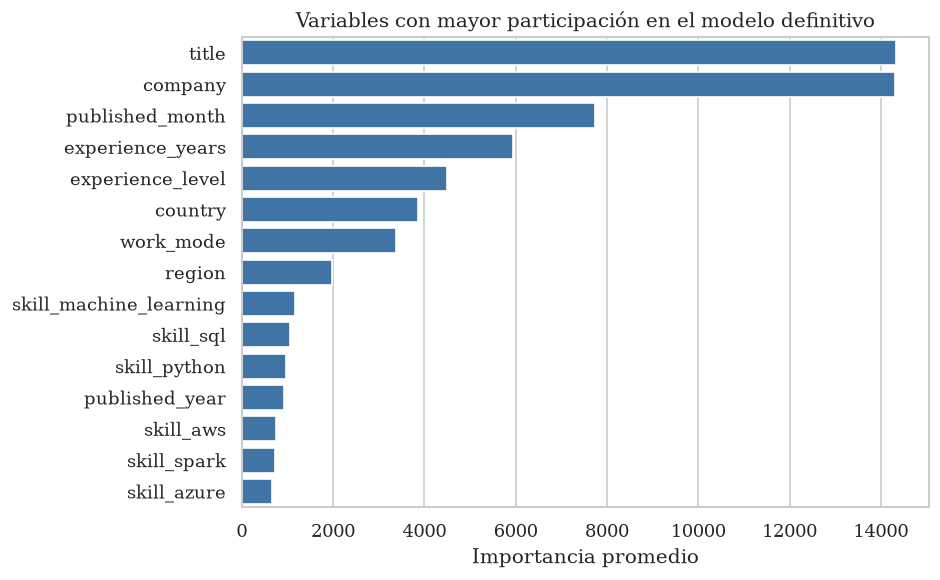

,variable,importancia
0,title,14333.5
5,company,14304.5
23,published_month,7729.5
7,experience_years,5946.0
3,experience_level,4490.5
1,country,3852.5
4,work_mode,3375.5
2,region,1971.5
17,skill_machine_learning,1156.5
10,skill_sql,1064.5


In [12]:
skill_sets={'sin_habilidades':[], 'python_sql':['python','sql'],
            'datos_nube':['python','sql','aws','spark'],
            'mlops':['python','machine_learning','docker','kubernetes','aws']}
skill_rows=[]
for label,skills in skill_sets.items():
    row={**base}
    for skill in SKILLS:row[f'skill_{skill}']=int(skill in skills)
    row['escenario']=label;skill_rows.append(row)
skill_frame=pd.DataFrame(skill_rows)
skill_pred=predict_range(skill_frame[X.columns])
skill_result=pd.DataFrame({'escenario':skill_frame.escenario,'pred_y1':skill_pred[:,0],'pred_y2':skill_pred[:,1]})
skill_result['punto_medio']=(skill_result.pred_y1+skill_result.pred_y2)/2
display(skill_result.style.format({c:'USD {:,.0f}' for c in ['pred_y1','pred_y2','punto_medio']}))

if selected_model=='catboost':
    feature_names=np.asarray(X.columns);importance=np.mean([model.feature_importances_ for model in final_models],axis=0)
else:
    feature_names=final_models[0].named_steps['preprocesamiento'].get_feature_names_out()
    estimators=[model.named_steps['modelo'] for model in final_models]
    if selected_model=='ridge':importance=np.mean([np.abs(model.coef_) for model in estimators],axis=0)
    else:importance=np.mean([model.feature_importances_ for model in estimators],axis=0)
importance_df=pd.DataFrame({'variable':feature_names,'importancia':importance}).sort_values('importancia',ascending=False)
fig,ax=plt.subplots(figsize=(8,5))
sns.barplot(data=importance_df.head(15),y='variable',x='importancia',color='#2F75B5',ax=ax)
ax.set(xlabel='Importancia promedio',ylabel='',title='Variables con mayor participación en el modelo definitivo')
plt.tight_layout();plt.show()
display(importance_df.head(15))

## 13. Conclusiones del modelo definitivo

El modelo definitivo se selecciona por validación temporal y se acompaña de un diagnóstico independiente de estabilidad. La evidencia debe mostrar si supera la línea base, cómo cambia entre ventanas futuras y si produce rangos positivos y ordenados. La evaluación por segmentos permite identificar mercados o niveles de experiencia donde el error continúa siendo alto; estos resultados deben convertirse en advertencias de cobertura en el tablero.

Las diferencias por geografía, experiencia o habilidades representan asociaciones presentes en publicaciones laborales. No deben interpretarse como efectos causales ni como una recomendación salarial individual. La versión desplegada deberá conservar la fecha, las métricas, los límites operativos y los conteos de soporte utilizados en este notebook.

In [13]:
support={'country':X.loc[trainval_idx,'country'].value_counts().to_dict(),
         'experience_level':X.loc[trainval_idx,'experience_level'].value_counts().to_dict(),
         'work_mode':X.loc[trainval_idx,'work_mode'].value_counts().to_dict()}
bundle={'version':'modelo-definitivo-v1','created_at':pd.Timestamp.utcnow().isoformat(),
        'comparison_input':comparison_selection,
        'model_family':selected_model,'model_class':type(final_models[0]).__name__,
        'configuration':winner,'parameters':configurations[winner],
        'selection_rule':'menor MAE de validación entre configuraciones con mejora >=10% sobre la mediana',
        'generalization_diagnostic':{'backtest_mae':back_mae,'validation_mae':selected_row.val_mae_promedio,
                                     'relative_gap':temporal_gap,'within_25_percent':stable},
        'uncertainty':{'method':'residuo conjunto calibrado en validación','nominal_coverage':.80,
                       'margin_usd':uncertainty_margin,'test_coverage':uncertainty_coverage},
        'target_scope':'rangos completamente reportados','targets':TARGETS,'feature_columns':list(X.columns),
        'categorical_columns':cat_cols,'skills':SKILLS,'limits':train_limits,'support':support,
        'validation_results':leaderboard.to_dict(orient='records'),'test_metrics':test_scores,
        'models':dict(zip(TARGETS,final_models)),'seed':SEED}
joblib.dump(bundle,ARTIFACT_DIR/'salary_range_model_final.joblib',compress=3)
pd.DataFrame({'id':model_df.loc[test_idx,'id'].astype(str),'y_min':model_df.loc[test_idx,'y_min_usd'],
              'y_max':model_df.loc[test_idx,'y_max_usd'],'pred_min':test_prediction[:,0],
              'pred_max':test_prediction[:,1]}).to_csv(ARTIFACT_DIR/'predicciones_prueba_final.csv',index=False)
with open(ARTIFACT_DIR/'metricas_modelo_final.json','w') as file:
    json.dump({'configuration':winner,'parameters':configurations[winner],
               'test_metrics':test_scores,'quality_checks':checks},file,indent=2,default=str)
print('Modelo definitivo:',ARTIFACT_DIR/'salary_range_model_final.joblib')

Modelo definitivo: /Users/franciscolozano/Downloads/PROYECTOS_MAIA/PROYECTO_DE_GRADO/MICROPROYECTO_GITHUB/artifacts/salary_range_model_final.joblib
